# 🍛 Indian Food Classifier v2 — Fast + 90% Accuracy
**Changes from v1:** EfficientNetV2-S backbone, IMG_SIZE=224, faster augmentation pipeline,
live per-batch progress, optimized DataLoader. Targets ~10-15 min/epoch on RTX 3050 6GB.

## Cell 1 — Install

In [1]:
# !pip install -q timm albumentations torchmetrics grad-cam
# !pip install -q matplotlib seaborn scikit-learn tqdm pillow

## Cell 2 — Imports & Config

In [1]:
import os, math, random, json, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
CFG = dict(
    DATA_DIR         = './food_dataset',
    AUGMENTED_DIR    = './food_dataset_augmented',
    CHECKPOINT_DIR   = './checkpoints',
    LOG_DIR          = './logs',

    # ── Model (fast & accurate for 6GB VRAM) ──────────────────────────────────
    MODEL_NAME       = 'tf_efficientnetv2_b0',   # faster than v2-s, still strong transfer learning
    PRETRAINED       = True,
    IMG_SIZE         = 192,                      # smaller input = much faster epoch time
    DROP_RATE        = 0.25,
    DROP_PATH_RATE   = 0.1,

    # ── Training ──────────────────────────────────────────────────────────────
    SEED             = 42,
    NUM_EPOCHS       = 30,
    BATCH_SIZE       = 24,                       # safer on Windows notebooks
    ACCUMULATE_GRAD  = 1,
    LR_HEAD          = 3e-4,
    LR_BACKBONE      = 3e-5,
    WEIGHT_DECAY     = 1e-4,
    WARMUP_EPOCHS    = 2,
    UNFREEZE_EPOCH   = 4,
    LABEL_SMOOTHING  = 0.1,
    MIXUP_ALPHA      = 0.0,
    CUTMIX_ALPHA     = 0.0,
    CUTMIX_PROB      = 0.0,
    FOCAL_GAMMA      = 2.0,
    ARC_SCALE        = 30.0,
    ARC_MARGIN       = 0.35,
    USE_ARC          = True,
    TTA_AUGMENTS     = 4,

    # ── Data ──────────────────────────────────────────────────────────────────
    TARGET_PER_CLASS = 180,
    VAL_SPLIT        = 0.15,
    TEST_SPLIT       = 0.15,

    # ── Hardware ──────────────────────────────────────────────────────────────
    NUM_WORKERS      = 2,
    PIN_MEMORY       = True,
)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False   # False = faster on GPU
    torch.backends.cudnn.benchmark     = True    # True  = faster on fixed input size

seed_everything(CFG['SEED'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for d in [CFG['CHECKPOINT_DIR'], CFG['LOG_DIR']]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## Cell 3 — Dataset Scan & Class Distribution

Classes : 106
Images  : 16,660
Min/Max : 49 / 200


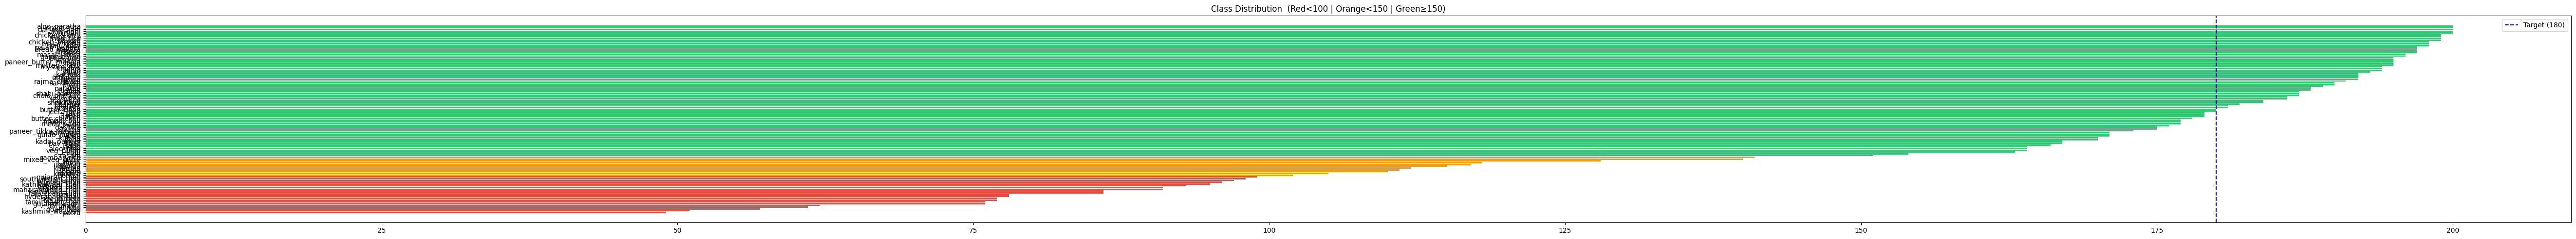

In [2]:
VALID_EXT   = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
DATA_DIR    = Path(CFG['DATA_DIR'])
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES  = len(class_names)

all_paths, all_labels = [], []
for cls in class_names:
    imgs = [p for p in (DATA_DIR/cls).iterdir() if p.suffix.lower() in VALID_EXT]
    all_paths.extend(imgs)
    all_labels.extend([class_to_idx[cls]] * len(imgs))

counts   = Counter(all_labels)
count_df = pd.DataFrame({'Class': [class_names[i] for i in counts],
                          'Count': list(counts.values())}).sort_values('Count')

print(f'Classes : {NUM_CLASSES}')
print(f'Images  : {len(all_paths):,}')
print(f'Min/Max : {count_df.Count.min()} / {count_df.Count.max()}')

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES//2), 5))
colors  = ['#e74c3c' if c < 100 else '#f39c12' if c < 150 else '#2ecc71'
           for c in count_df['Count']]
ax.barh(count_df['Class'], count_df['Count'], color=colors)
ax.axvline(CFG['TARGET_PER_CLASS'], color='navy', linestyle='--',
           label=f"Target ({CFG['TARGET_PER_CLASS']})")
ax.set_title('Class Distribution  (Red<100 | Orange<150 | Green≥150)')
ax.legend(); plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/class_dist.png", dpi=120); plt.show()

## Cell 4 — Offline Augmentation (Balance Classes)

In [4]:
import shutil

OFFLINE_AUG = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15,
                       rotate_limit=20, border_mode=0, p=0.7),
    A.OneOf([
        A.RandomBrightnessContrast(0.3, 0.3, p=1.0),
        A.HueSaturationValue(15, 30, 20, p=1.0),
        A.CLAHE(clip_limit=4, p=1.0),
    ], p=0.7),
    A.OneOf([
        A.GridDistortion(distort_limit=0.3, p=1.0),
        A.ElasticTransform(alpha=80, sigma=10, p=1.0),
    ], p=0.4),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.GaussNoise(var_limit=(10, 40), p=0.2),
])

def augment_and_balance():
    target   = CFG['TARGET_PER_CLASS']
    aug_root = Path(CFG['AUGMENTED_DIR'])
    src_root = Path(CFG['DATA_DIR'])
    generated = 0

    for cls in tqdm(class_names, desc='Balancing'):
        dst_dir = aug_root / cls
        dst_dir.mkdir(parents=True, exist_ok=True)
        src_imgs = sorted([p for p in (src_root/cls).iterdir()
                           if p.suffix.lower() in VALID_EXT])
        # Copy originals
        for p in src_imgs:
            dst = dst_dir / p.name
            if not dst.exists(): shutil.copy2(p, dst)

        needed = target - len(src_imgs)
        for i in range(max(0, needed)):
            src   = random.choice(src_imgs)
            img   = np.array(Image.open(src).convert('RGB'))
            aug   = OFFLINE_AUG(image=img)['image']
            Image.fromarray(aug).save(dst_dir / f'aug_{i:05d}_{src.stem}.jpg', quality=90)
            generated += 1

    print(f'\n✅ Done. Generated {generated:,} augmented images.')

augment_and_balance()

aug_counts = {c: len(list((Path(CFG['AUGMENTED_DIR'])/c).glob('*'))) for c in class_names}
print(f'Post-aug  Min:{min(aug_counts.values())}  Max:{max(aug_counts.values())}  '
      f'Mean:{np.mean(list(aug_counts.values())):.0f}')

Balancing: 100%|██████████| 106/106 [13:24<00:00,  7.59s/it]



✅ Done. Generated 9,840 augmented images.
Post-aug  Min:250  Max:250  Mean:250


## Cell 5 — Train / Val / Test Split

In [3]:
aug_root = Path(CFG['AUGMENTED_DIR'])
aug_paths, aug_labels = [], []
for cls in class_names:
    imgs = sorted([p for p in (aug_root/cls).iterdir() if p.suffix.lower() in VALID_EXT])
    aug_paths.extend(imgs)
    aug_labels.extend([class_to_idx[cls]] * len(imgs))

aug_paths  = np.array(aug_paths)
aug_labels = np.array(aug_labels)

sss1 = StratifiedShuffleSplit(1, test_size=CFG['TEST_SPLIT'], random_state=CFG['SEED'])
tv_idx, test_idx = next(sss1.split(aug_paths, aug_labels))

sss2 = StratifiedShuffleSplit(1, test_size=CFG['VAL_SPLIT']/(1-CFG['TEST_SPLIT']),
                               random_state=CFG['SEED'])
rel_tr, rel_val = next(sss2.split(aug_paths[tv_idx], aug_labels[tv_idx]))

train_paths, train_labels = aug_paths[tv_idx[rel_tr]],  aug_labels[tv_idx[rel_tr]]
val_paths,   val_labels   = aug_paths[tv_idx[rel_val]], aug_labels[tv_idx[rel_val]]
test_paths,  test_labels  = aug_paths[test_idx],        aug_labels[test_idx]

print(f'Train:{len(train_paths):,}  Val:{len(val_paths):,}  Test:{len(test_paths):,}')

with open(f"{CFG['CHECKPOINT_DIR']}/class_mapping.json", 'w') as f:
    json.dump({'class_to_idx': class_to_idx,
               'idx_to_class': {v:k for k,v in class_to_idx.items()}}, f, indent=2)
print('Class mapping saved.')

Train:18,549  Val:3,976  Test:3,975
Class mapping saved.


## Cell 6 — Transforms

In [4]:
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]
SZ       = CFG['IMG_SIZE']

train_transform = A.Compose([
    A.RandomResizedCrop(size=(SZ, SZ), scale=(0.65, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.ColorJitter(0.4, 0.4, 0.4, 0.1, p=1.0),
        A.HueSaturationValue(20, 40, 30, p=1.0),
    ], p=0.8),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50), p=1.0),
        A.ISONoise(p=1.0),
    ], p=0.25),
    A.OneOf([
        A.GridDistortion(distort_limit=0.2, p=1.0),
        A.ElasticTransform(alpha=60, sigma=8, p=1.0),
    ], p=0.25),
    A.CoarseDropout(max_holes=8, max_height=SZ//8, max_width=SZ//8, p=0.35),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=SZ+32, width=SZ+32),
    A.CenterCrop(height=SZ, width=SZ),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

tta_transform = A.Compose([
    A.RandomResizedCrop(size=(SZ, SZ), scale=(0.8, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(0.1, 0.1, 0.1, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print('✅ Transforms ready.')

✅ Transforms ready.


## Cell 7 — Dataset & DataLoaders

In [5]:
class IndianFoodDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths; self.labels = labels; self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = np.array(Image.open(self.paths[idx]).convert('RGB'))
        except Exception:
            img = np.ones((SZ, SZ, 3), dtype=np.uint8) * 128
        if self.transform:
            img = self.transform(image=img)['image']
        return img, self.labels[idx]


# Windows notebooks are most reliable with num_workers=0.
# This avoids the common "stuck at 0%" DataLoader hang on first batch.
NW = 0 if os.name == 'nt' else CFG['NUM_WORKERS']
PIN = CFG['PIN_MEMORY'] and DEVICE.type == 'cuda'
loader_kwargs = dict(num_workers=NW, pin_memory=PIN)
if NW > 0:
    loader_kwargs['persistent_workers'] = True
    loader_kwargs['prefetch_factor'] = 2

train_ds = IndianFoodDataset(train_paths, train_labels, train_transform)
val_ds   = IndianFoodDataset(val_paths,   val_labels,   val_transform)
test_ds  = IndianFoodDataset(test_paths,  test_labels,  val_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_ds,
    batch_size=CFG['BATCH_SIZE'] * 2,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_ds,
    batch_size=CFG['BATCH_SIZE'] * 2,
    shuffle=False,
    **loader_kwargs,
)

print(f'Loader workers: {NW}  |  pin_memory={PIN}')
print(f'Train batches:{len(train_loader)}  Val:{len(val_loader)}  Test:{len(test_loader)}')

sample_imgs, sample_lbls = next(iter(train_loader))
print(f'Sample batch -> images: {tuple(sample_imgs.shape)}  labels: {tuple(sample_lbls.shape)}')

Loader workers: 0  |  pin_memory=True
Train batches:772  Val:83  Test:83
Sample batch -> images: (24, 3, 192, 192)  labels: (24,)


## Cell 8 — Model (EfficientNetV2-S + ArcFace)

In [6]:
class ArcFaceHead(nn.Module):
    def __init__(self, in_features, num_classes, scale=30.0, margin=0.5):
        super().__init__()
        self.scale  = scale; self.margin = margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, labels=None):
        x = F.normalize(x, dim=1)
        w = F.normalize(self.weight, dim=1)
        cos = F.linear(x, w).clamp(-1+1e-7, 1-1e-7)
        if labels is None or not self.training:
            return cos * self.scale
        theta   = cos.acos()
        one_hot = torch.zeros_like(cos).scatter_(1, labels.view(-1,1), 1)
        cos_m   = (theta + self.margin * one_hot).cos()
        return (cos + one_hot * (cos_m - cos)) * self.scale


class IndianFoodClassifier(nn.Module):
    def __init__(self, num_classes, cfg):
        super().__init__()
        self.backbone = timm.create_model(
            cfg['MODEL_NAME'], pretrained=cfg['PRETRAINED'],
            num_classes=0, global_pool='avg',
            drop_rate=cfg['DROP_RATE'], drop_path_rate=cfg['DROP_PATH_RATE'])
        feat = self.backbone.num_features
        self.neck = nn.Sequential(
            nn.Linear(feat, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256))
        self.head    = ArcFaceHead(256, num_classes, cfg['ARC_SCALE'], cfg['ARC_MARGIN'])
        self.use_arc = cfg['USE_ARC']
        self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def unfreeze_backbone(self, blocks=3):
        for p in self.backbone.parameters(): p.requires_grad = True
        stages       = list(self.backbone.children())
        freeze_until = max(0, len(stages) - blocks)
        for i, child in enumerate(stages):
            if i < freeze_until:
                for p in child.parameters(): p.requires_grad = False
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  Trainable params after unfreeze: {n:,}')

    def forward(self, x, labels=None):
        feat   = self.backbone(x)
        emb    = self.neck(feat)
        logits = self.head(emb, labels) if self.use_arc else self.head(emb)
        return logits, emb


model = IndianFoodClassifier(NUM_CLASSES, CFG).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {train:,}  (backbone frozen for first {CFG["UNFREEZE_EPOCH"]} epochs)')

Total params    : 6,674,576
Trainable params: 815,872  (backbone frozen for first 4 epochs)


## Cell 9 — Loss, MixUp/CutMix, Optimizer, Scheduler

In [7]:
# ── Focal Loss + Label Smoothing ──────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, num_classes, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.K = num_classes; self.gamma = gamma; self.sm = smoothing

    def forward(self, logits, targets):
        with torch.no_grad():
            st = torch.zeros_like(logits).fill_(self.sm / (self.K - 1))
            st.scatter_(1, targets.unsqueeze(1), 1.0 - self.sm)
        lp    = F.log_softmax(logits, dim=1)
        pt    = lp.exp().gather(1, targets.unsqueeze(1)).squeeze()
        focal = (1 - pt) ** self.gamma
        ce    = -(st * lp).sum(dim=1)
        return (focal * ce).mean()

# Balanced classes + transfer learning generally train faster and more stably
# with plain cross-entropy + label smoothing than focal loss here.
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['LABEL_SMOOTHING']).to(DEVICE)

# ── MixUp / CutMix ────────────────────────────────────────────────────────────
def mixup(imgs, lbls, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    return lam*imgs + (1-lam)*imgs[idx], lbls, lbls[idx], lam

def rand_bbox(size, lam):
    W,H = size[3],size[2]
    r   = np.sqrt(1-lam)
    cw,ch = int(W*r), int(H*r)
    cx,cy = np.random.randint(W), np.random.randint(H)
    return max(cx-cw//2,0),max(cy-ch//2,0),min(cx+cw//2,W),min(cy+ch//2,H)

def cutmix(imgs, lbls, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    x1,y1,x2,y2 = rand_bbox(imgs.size(), lam)
    out = imgs.clone(); out[:,:,y1:y2,x1:x2] = imgs[idx,:,y1:y2,x1:x2]
    lam_adj = 1 - (x2-x1)*(y2-y1)/(imgs.size(-1)*imgs.size(-2))
    return out, lbls, lbls[idx], lam_adj

def mix_loss(crit, logits, la, lb, lam):
    return lam*crit(logits,la) + (1-lam)*crit(logits,lb)

# ── Optimizer ─────────────────────────────────────────────────────────────────
def build_optimizer(model, cfg):
    bb = [p for n,p in model.named_parameters() if 'backbone' in n and p.requires_grad]
    hd = [p for n,p in model.named_parameters() if 'backbone' not in n and p.requires_grad]
    return torch.optim.AdamW(
        [{'params':hd,'lr':cfg['LR_HEAD'],'name':'head'},
         {'params':bb,'lr':cfg['LR_BACKBONE'],'name':'backbone'}],
        weight_decay=cfg['WEIGHT_DECAY'])

def build_scheduler(opt, epochs, warmup, steps_per_epoch):
    ws = warmup * steps_per_epoch
    ts = epochs * steps_per_epoch
    def fn(s):
        if s < ws: return s / max(1, ws)
        p = (s-ws) / max(1, ts-ws)
        return max(0.0, 0.5*(1+math.cos(math.pi*p)))
    return torch.optim.lr_scheduler.LambdaLR(opt, fn)

optimizer = build_optimizer(model, CFG)
scheduler = build_scheduler(optimizer, CFG['NUM_EPOCHS'],
                             CFG['WARMUP_EPOCHS'], len(train_loader))
scaler    = torch.amp.GradScaler('cuda', enabled=DEVICE.type=='cuda')

print('✅ Loss, augmentation, optimizer, scheduler ready.')

✅ Loss, augmentation, optimizer, scheduler ready.


## Cell 10 — Train & Validate Functions (Live Display)

In [8]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, criterion, epoch_idx):
    model.train()
    total_loss = correct = total = 0
    optimizer.zero_grad(set_to_none=True)
    batch_bar = tqdm(loader, desc=f'Epoch {epoch_idx} [train]', leave=False, dynamic_ncols=True, mininterval=0.5)

    for step, (imgs, lbls) in enumerate(batch_bar, 1):
        imgs = imgs.to(DEVICE, non_blocking=True).float()
        lbls = lbls.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=DEVICE.type=='cuda'):
            logits, _ = model(imgs, lbls) if CFG['USE_ARC'] else model(imgs)
            loss = criterion(logits, lbls) / CFG['ACCUMULATE_GRAD']

        scaler.scale(loss).backward()

        if (step % CFG['ACCUMULATE_GRAD'] == 0) or (step == len(loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        total_loss += loss.item() * CFG['ACCUMULATE_GRAD']
        preds       = logits.argmax(1)
        correct    += (preds == lbls).sum().item()
        total      += lbls.size(0)

        batch_bar.set_postfix(
            loss=f'{total_loss/step:.4f}',
            acc=f'{100.*correct/total:.1f}%',
            lr=f'{optimizer.param_groups[0]["lr"]:.1e}'
        )

    batch_bar.close()
    return total_loss / max(1, len(loader)), 100. * correct / max(1, total)


@torch.inference_mode()
def validate(model, loader, criterion, epoch_idx):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_targets = [], []
    batch_bar = tqdm(loader, desc=f'Epoch {epoch_idx} [val]', leave=False, dynamic_ncols=True, mininterval=0.5)

    for step, (imgs, lbls) in enumerate(batch_bar, 1):
        imgs = imgs.to(DEVICE, non_blocking=True).float()
        lbls = lbls.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=DEVICE.type=='cuda'):
            logits, _ = model(imgs)
            loss = criterion(logits, lbls)
        total_loss += loss.item()
        preds       = logits.argmax(1)
        correct    += (preds == lbls).sum().item()
        total      += lbls.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(lbls.cpu().numpy())

        batch_bar.set_postfix(
            loss=f'{total_loss/step:.4f}',
            acc=f'{100.*correct/total:.1f}%'
        )

    batch_bar.close()
    return total_loss / max(1, len(loader)), 100. * correct / max(1, total), all_preds, all_targets


print('✅ Train/Val functions ready.')

✅ Train/Val functions ready.


## Cell 11 — Training Loop

In [9]:
history      = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
best_val_acc = 0.0
patience_ctr = 0
PATIENCE     = 8
CKPT_PATH    = f"{CFG['CHECKPOINT_DIR']}/best_model.pth"

# ── Header ────────────────────────────────────────────────────────────────────
W = 82
print('═'*W)
print(f"  Model:{CFG['MODEL_NAME']}  |  Classes:{NUM_CLASSES}  |  Device:{DEVICE}")
print(f"  Epochs:{CFG['NUM_EPOCHS']}  |  Batch:{CFG['BATCH_SIZE']} (eff.{CFG['BATCH_SIZE']*CFG['ACCUMULATE_GRAD']})  |  IMG:{SZ}px")
print('═'*W)
HDR = f"{'Ep':>5}  {'TrnLoss':>8}  {'TrnAcc%':>8}  {'ValLoss':>8}  {'ValAcc%':>8}  {'Best%':>7}  {'LR':>8}  {'Time':>7}"
print(HDR)
print('─'*W)

print('Starting training... batch progress will appear inside each epoch.')
epoch_bar = tqdm(range(1, CFG['NUM_EPOCHS'] + 1), desc='Epochs', unit='ep', dynamic_ncols=True)

for epoch in epoch_bar:
    # Progressive unfreeze
    if epoch == CFG['UNFREEZE_EPOCH']:
        tqdm.write(f'\n  ▶ Epoch {epoch}: Unfreezing backbone...')
        model.unfreeze_backbone(blocks=3)
        optimizer = build_optimizer(model, CFG)
        scheduler = build_scheduler(optimizer, CFG['NUM_EPOCHS'] - epoch + 1,
                                    0, len(train_loader))
        scaler    = torch.amp.GradScaler('cuda', enabled=DEVICE.type=='cuda')

    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                      scheduler, scaler, criterion, epoch)
    vl_loss, vl_acc, vl_preds, vl_tgts = validate(model, val_loader,
                                                  criterion, epoch)
    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']
    is_best = vl_acc > best_val_acc

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);  history['val_acc'].append(vl_acc)

    if is_best:
        best_val_acc = vl_acc; patience_ctr = 0
        torch.save({'epoch':epoch,'model_state':model.state_dict(),
                    'val_acc':vl_acc,'class_names':class_names,'cfg':CFG}, CKPT_PATH)
    else:
        patience_ctr += 1

    m, s   = divmod(int(elapsed), 60)
    flag   = ' 💾' if is_best else f' ⏳{patience_ctr}/{PATIENCE}'
    row    = (f"{epoch:02d}/{CFG['NUM_EPOCHS']:>3}  {tr_loss:>8.4f}  {tr_acc:>8.2f}  "
              f"{vl_loss:>8.4f}  {vl_acc:>8.2f}  {best_val_acc:>7.2f}  "
              f"{lr_now:>8.1e}  {m}m{s:02d}s")
    tqdm.write(row + flag)

    epoch_bar.set_postfix(train=f'{tr_acc:.1f}%', val=f'{vl_acc:.1f}%', best=f'{best_val_acc:.1f}%')

    if patience_ctr >= PATIENCE:
        tqdm.write(f'\n  ⛔ Early stopping — no improvement for {PATIENCE} epochs.')
        break

epoch_bar.close()
print(f'  ✅ Training complete.  Best Val Accuracy: {best_val_acc:.2f}%')
print('═'*W)

══════════════════════════════════════════════════════════════════════════════════
  Model:tf_efficientnetv2_b0  |  Classes:106  |  Device:cuda
  Epochs:30  |  Batch:24 (eff.24)  |  IMG:192px
══════════════════════════════════════════════════════════════════════════════════
   Ep   TrnLoss   TrnAcc%   ValLoss   ValAcc%    Best%        LR     Time
──────────────────────────────────────────────────────────────────────────────────
Starting training... batch progress will appear inside each epoch.


Epochs:   0%|          | 0/30 [00:00<?, ?ep/s]

Epochs:   3%|▎         | 1/30 [19:48<9:34:12, 1188.00s/ep, best=24.2%, train=0.0%, val=24.2%]

01/ 30   14.6699      0.00    3.5820     24.17    24.17   1.5e-04  19m47s 💾


Epochs:   7%|▋         | 2/30 [33:34<7:35:12, 975.45s/ep, best=37.3%, train=0.1%, val=37.3%] 

...

28/ 30    9.8972      4.34    2.6077     53.77    54.18   4.0e-06  8m47s ⏳5/8


Epochs:  97%|█████████▋| 29/30 [7:33:59<46:23, 2783.93s/ep, best=54.2%, train=4.2%, val=53.3%]

29/ 30    9.9234      4.20    2.6197     53.32    54.18   1.0e-06  116m52s ⏳6/8


Epochs: 100%|██████████| 30/30 [7:42:58<00:00, 925.96s/ep, best=54.2%, train=4.6%, val=53.6%] 

30/ 30    9.8914      4.60    2.6220     53.62    54.18   0.0e+00  8m59s ⏳7/8
  ✅ Training complete.  Best Val Accuracy: 54.18%
══════════════════════════════════════════════════════════════════════════════════


## Cell 12 — Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train', color='#e74c3c')
axes[0].plot(history['val_loss'],   label='Val',   color='#3498db')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_acc'], label='Train', color='#e74c3c')
axes[1].plot(history['val_acc'],   label='Val',   color='#3498db')
axes[1].axhline(90, color='green', linestyle='--', label='90% target')
axes[1].set_title('Accuracy'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/training_curves.png", dpi=150)
plt.show()

## Cell 13 — Test Evaluation with TTA

In [ ]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded checkpoint — epoch {ckpt['epoch']}, val acc {ckpt['val_acc']:.2f}%")

@torch.no_grad()
def evaluate_tta(model, paths, labels, n_tta=6):
    model.eval()
    all_preds, all_probs = [], []

    for path, lbl in tqdm(zip(paths, labels), total=len(paths), desc='TTA Inference'):
        img  = np.array(Image.open(path).convert('RGB'))
        views = torch.stack([tta_transform(image=img)['image']
                             for _ in range(n_tta)]).to(DEVICE).float()
        with torch.cuda.amp.autocast(enabled=DEVICE.type=='cuda'):
            logits, _ = model(views)
        probs = F.softmax(logits, dim=1).mean(0)
        all_preds.append(probs.argmax().item())
        all_probs.append(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_probs)

test_preds, test_probs = evaluate_tta(model, test_paths, test_labels,
                                       CFG['TTA_AUGMENTS'])
test_acc = 100. * (test_preds == test_labels).mean()
print(f'\n🎯 Test Accuracy (TTA x{CFG["TTA_AUGMENTS"]}): {test_acc:.2f}%')
print(classification_report(test_labels, test_preds,
                             target_names=class_names, digits=3))

## Cell 14 — Confusion Matrix

In [ ]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

h = max(12, NUM_CLASSES//2)
fig, ax = plt.subplots(figsize=(h, h))
sns.heatmap(cm_norm, annot=NUM_CLASSES<=30, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_title('Normalised Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/confusion_matrix.png", dpi=150)
plt.show()

# Top confused pairs
pairs = sorted([(cm[i,j], class_names[i], class_names[j])
                for i in range(NUM_CLASSES) for j in range(NUM_CLASSES)
                if i!=j and cm[i,j]>0], reverse=True)
print('\nTop-10 Confused Pairs:')
for cnt, t, p in pairs[:10]:
    print(f'  {t:30s} → {p:30s}  ({cnt})')

## Cell 15 — Per-Class Accuracy

In [ ]:
pca = cm.diagonal() / cm.sum(axis=1)
df  = pd.DataFrame({'Class':class_names,'Accuracy':pca*100}).sort_values('Accuracy')

fig, ax = plt.subplots(figsize=(max(12, NUM_CLASSES//2), 5))
colors  = ['#e74c3c' if a<70 else '#f39c12' if a<85 else '#2ecc71' for a in df['Accuracy']]
ax.barh(df['Class'], df['Accuracy'], color=colors)
ax.axvline(90, color='navy', linestyle='--', label='90% target')
ax.set_xlim(0, 105); ax.legend()
ax.set_title('Per-Class Accuracy  (Red<70 | Orange<85 | Green≥85)')
plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/per_class_acc.png", dpi=150)
plt.show()

weak = df[df['Accuracy'] < 80]
if len(weak): print('\nClasses below 80%:\n', weak.to_string(index=False))
else: print('\n✅ All classes above 80%!')

## Cell 16 — Single Image Inference

In [ ]:
@torch.no_grad()
def predict(img_path, n_tta=6, top_k=5):
    model.eval()
    img   = np.array(Image.open(img_path).convert('RGB'))
    views = torch.stack([tta_transform(image=img)['image']
                         for _ in range(n_tta)]).to(DEVICE).float()
    with torch.cuda.amp.autocast(enabled=DEVICE.type=='cuda'):
        logits, _ = model(views)
    probs       = F.softmax(logits,1).mean(0)
    topk_p, topk_i = probs.topk(top_k)
    results = [(class_names[i.item()], p.item()*100) for i,p in zip(topk_i,topk_p)]

    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
    ax1.imshow(Image.open(img_path).convert('RGB')); ax1.axis('off'); ax1.set_title('Input')
    names=[r[0] for r in results]; scores=[r[1] for r in results]
    cols=['#2ecc71' if i==0 else '#3498db' for i in range(len(names))]
    ax2.barh(names[::-1], scores[::-1], color=cols[::-1])
    ax2.set_xlim(0,105); ax2.set_xlabel('Confidence (%)')
    ax2.set_title(f'Top-{top_k} Predictions')
    for i,(n,s) in enumerate(zip(names[::-1],scores[::-1])):
        ax2.text(s+1,i,f'{s:.1f}%',va='center',fontsize=9)
    plt.tight_layout(); plt.show()
    print(f'\n🏆 {results[0][0]}  ({results[0][1]:.1f}%)')
    return results

# Demo on a random test image
idx  = random.randint(0, len(test_paths)-1)
print(f'True label: {class_names[test_labels[idx]]}')
predict(test_paths[idx])

## Cell 17 — Export TorchScript

In [ ]:
class DeployModel(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.backbone = m.backbone; self.neck = m.neck
        w = F.normalize(m.head.weight, dim=1)
        self.cls = nn.Linear(256, NUM_CLASSES, bias=False)
        self.cls.weight.data.copy_(w)
        self.scale = CFG['ARC_SCALE']

    def forward(self, x):
        return self.cls(F.normalize(self.neck(self.backbone(x)), dim=1)) * self.scale

model.eval()
deploy = DeployModel(model).to(DEVICE).eval()
dummy  = torch.randn(1, 3, SZ, SZ, device=DEVICE)
traced = torch.jit.trace(deploy, dummy)
ts_path = f"{CFG['CHECKPOINT_DIR']}/indian_food_classifier.pt"
traced.save(ts_path)
print(f'✅ TorchScript saved: {ts_path}')
out = torch.jit.load(ts_path).to(DEVICE).eval()(dummy)
print(f'   Output shape: {out.shape}  ← should be (1, {NUM_CLASSES})')